# Model Fitting and Evaluation

The main goal of this notebook is to fit the proposed models to the available data and perform a first visual evaluation of its performance, prior to the proper model validation, evaluation and interpretation.

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tumorgrowth-processed.csv"
EXPORT_PATH = PROJECT_ROOT / "figures"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.tumor_model_basic import simulate_tumor_basic
from src.models.tumor_model_advanced import simulate_tumor_advanced

from src.models.fit_model_basic import fit_model_basic, loss_function
from src.models.fit_model_advanced import fit_model_advanced

In [2]:
# 1. Load data
data = pd.read_csv(DATA_PATH)

data.head()

,Grp,Group,ID,Day,Size,Baseline,RTV
0,1.CTR,1,101,0,41.8,41.8,1.000000
1,1.CTR,1,101,3,85.0,41.8,2.033493
2,1.CTR,1,101,4,114.0,41.8,2.727273
3,1.CTR,1,101,5,162.3,41.8,3.882775
4,1.CTR,1,101,6,178.3,41.8,4.265550


## Basic Model

Firstly the basic mechanistic model will be fitted (it does not contemplate acquired resistance to treatment). This model will serve as a benchmark for the advanced one (which does contemplate acquired resistance), and it will be assessed whether the addition of the extra parameters improves significantly the performance of the model.

In [3]:
%%time
seed = 23 ; maxiter = 100 ; popsize = 10

results_df = fit_model_basic(data,
                             seed,
                             maxiter,
                             popsize)

C:\Users\usuari\Desktop\Projectes\tumor-modelling\src\models\fit_model_basic.py:11: RuntimeWarning: divide by zero encountered in log
  return float(np.mean((np.log(T_obs) - np.log(T_pred)) ** 2))


CPU times: total: 2min 40s
Wall time: 2min 47s


In [4]:
results_df.head(10)

,Group,r,K,al,MSE
0,1,0.311208,4002.503633,0.000000,0.290477
1,2,0.311208,4002.503633,0.119995,0.290477
2,3,0.311208,4002.503633,0.075330,0.290477
3,4,0.311208,4002.503633,0.127209,0.290477


In order to get an idea of the behavior of the basic model it is helpful to plot several instances of the prediction against the observed values.

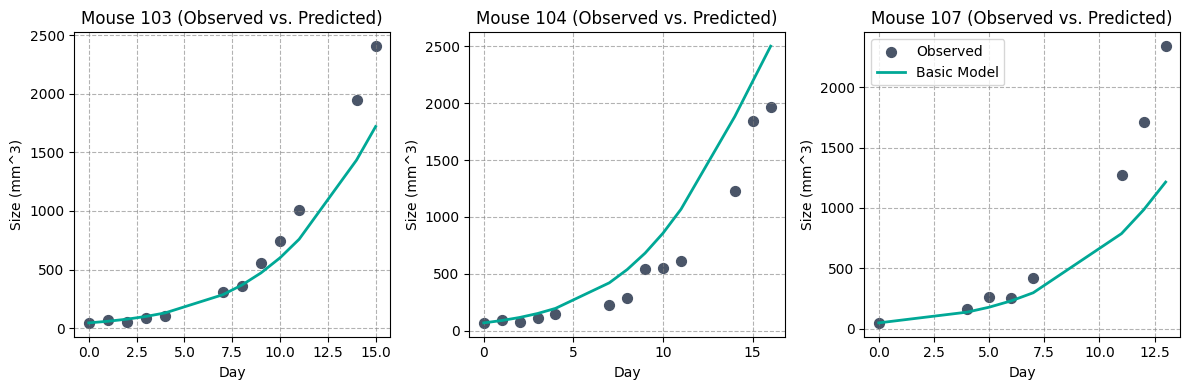

In [13]:
import random

# Group 1 (Control group)
mice_grp1 = data[data["Group"] == 1]
id1, id2, id3 = random.sample(list(mice_grp1["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r = results_df["r"].iloc[0]
K = results_df["K"].iloc[0]
al = results_df.loc[results_df["Group"]==1, "al"].iloc[0]

D = False

sim_df1 = simulate_tumor_basic(
    T0=T0_1,
    r=r,
    K=K,
    al=al,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor_basic(
    T0=T0_2,
    r=r,
    K=K,
    al=al,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor_basic(
    T0=T0_3,
    r=r,
    K=K,
    al=al,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig4.png", dpi=300, bbox_inches="tight")
plt.show()

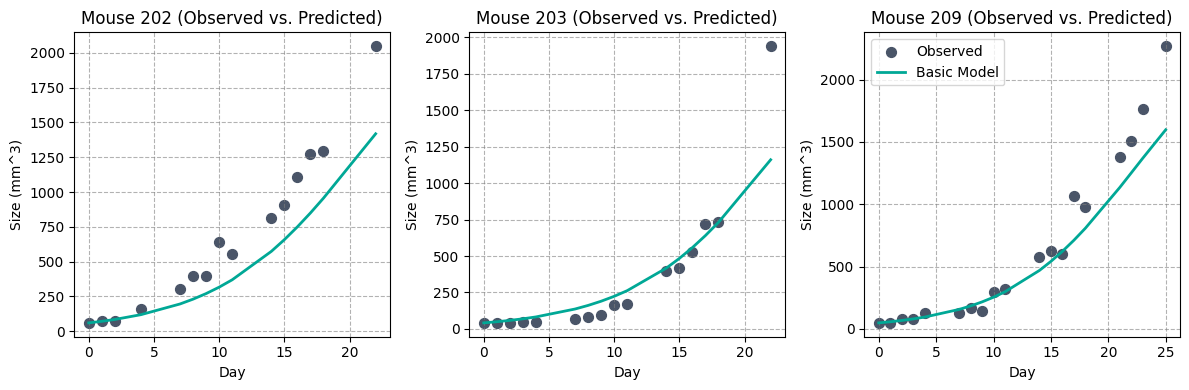

In [14]:
# Group 2 (Only drug)
mice_grp2 = data[data["Group"] == 2]
id1, id2, id3 = random.sample(list(mice_grp2["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r = results_df["r"].iloc[0]
K = results_df["K"].iloc[0]
al = results_df.loc[results_df["Group"]==2, "al"].iloc[0]

D = True

sim_df1 = simulate_tumor_basic(
    T0=T0_1,
    r=r,
    K=K,
    al=al,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor_basic(
    T0=T0_2,
    r=r,
    K=K,
    al=al,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor_basic(
    T0=T0_3,
    r=r,
    K=K,
    al=al,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig5.png", dpi=300, bbox_inches="tight")
plt.show()

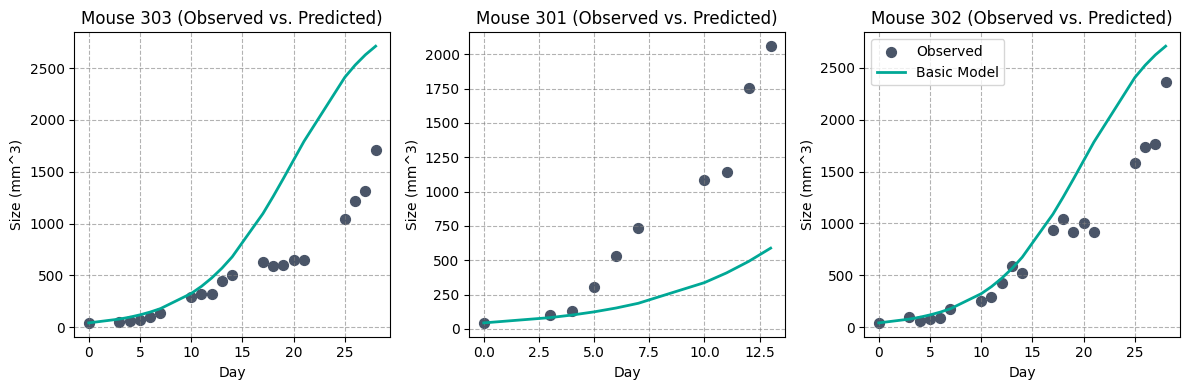

In [20]:
# Group 3 (Only radiation)
mice_grp3 = data[data["Group"] == 3]
id1, id2, id3 = random.sample(list(mice_grp3["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r = results_df["r"].iloc[0]
K = results_df["K"].iloc[0]
al = results_df.loc[results_df["Group"]==3, "al"].iloc[0]

D = True

sim_df1 = simulate_tumor_basic(
    T0=T0_1,
    r=r,
    K=K,
    al=al,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor_basic(
    T0=T0_2,
    r=r,
    K=K,
    al=al,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor_basic(
    T0=T0_3,
    r=r,
    K=K,
    al=al,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig6.png", dpi=300, bbox_inches="tight")
plt.show()

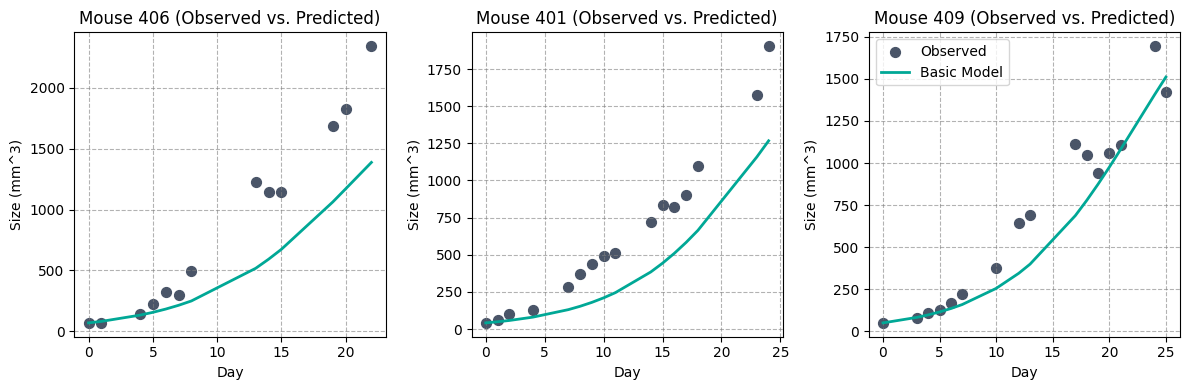

In [21]:
# Group 4 (Drug + Radiation)
mice_grp4 = data[data["Group"] == 4]
id1, id2, id3 = random.sample(list(mice_grp4["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r = results_df["r"].iloc[0]
K = results_df["K"].iloc[0]
al = results_df.loc[results_df["Group"]==4, "al"].iloc[0]

D = True

sim_df1 = simulate_tumor_basic(
    T0=T0_1,
    r=r,
    K=K,
    al=al,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor_basic(
    T0=T0_2,
    r=r,
    K=K,
    al=al,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor_basic(
    T0=T0_3,
    r=r,
    K=K,
    al=al,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig7.png", dpi=300, bbox_inches="tight")
plt.show()

In general the model manages to fairly fit the data, however it does have trouble with in-group variability. This evaluation will further be analyzed in the next notebook.

## Advanced Model

Next the advanced model (which contemplates acquired resistance to treatment) will be fitted to the available data.

In [22]:
%%time
seed = 23 ; maxiter = 100 ; popsize = 10

results_df = fit_model_advanced(data, seed, maxiter, popsize)
results_df.head(10)

CPU times: total: 6min 7s
Wall time: 7min 4s


,Group,r_s,r_r,K,mu,al,MSE
0,1,0.337268,0.01,4055.517902,0.05,0.000000,0.28001
1,2,0.337268,0.01,4055.517902,0.05,0.115620,0.28001
2,3,0.337268,0.01,4055.517902,0.05,0.070870,0.28001
3,4,0.337268,0.01,4055.517902,0.05,0.123184,0.28001


With the objective of getting an idea of the behavior of the model in the following several instances of plots for each group will be shown.

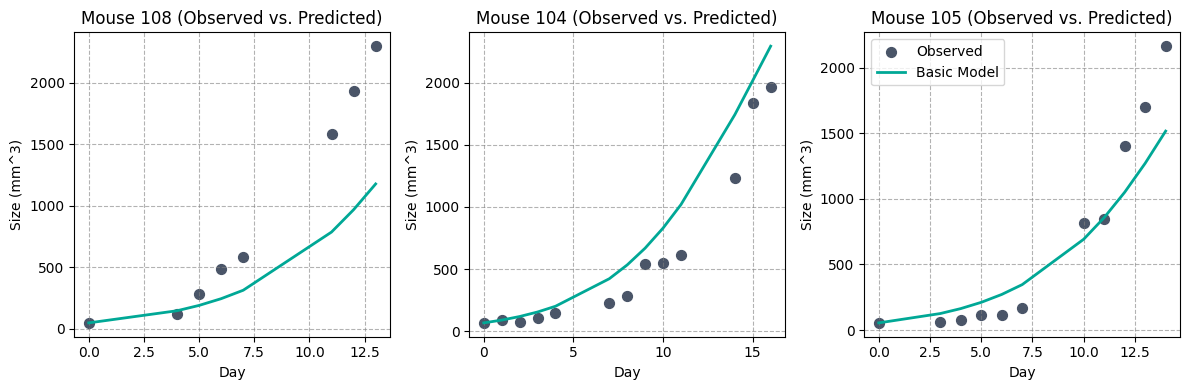

In [25]:
# Group 1 (Control group)
mice_grp1 = data[data["Group"] == 1]
id1, id2, id3 = random.sample(list(mice_grp1["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r_s = results_df["r_s"].iloc[0]
r_r = results_df["r_r"].iloc[0]
mu = results_df["mu"].iloc[0]
K = results_df["K"].iloc[0]
al = results_df.loc[results_df["Group"]==1, "al"].iloc[0]

D = False

sim_df1 = simulate_tumor_advanced(
    T0=T0_1,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor_advanced(
    T0=T0_2,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor_advanced(
    T0=T0_3,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig8.png", dpi=300, bbox_inches="tight")
plt.show()

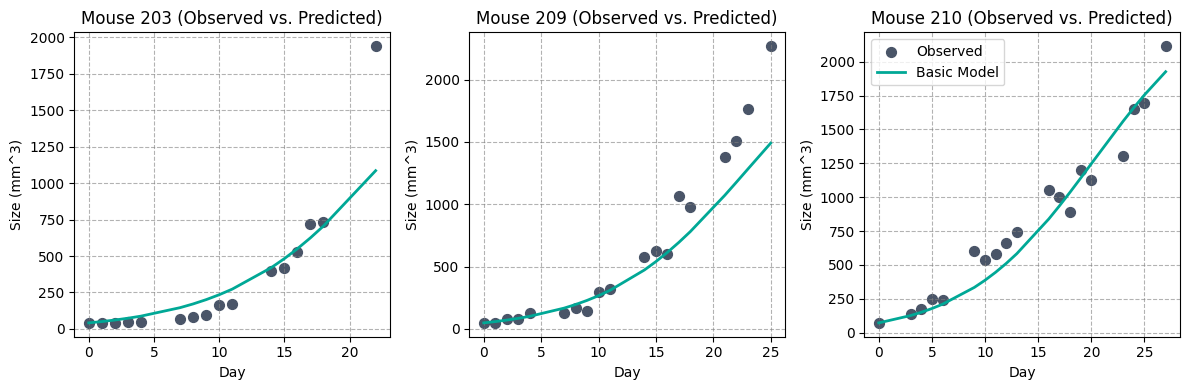

In [26]:
# Group 2 (Only drug)
mice_grp2 = data[data["Group"] == 2]
id1, id2, id3 = random.sample(list(mice_grp2["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r_s = results_df["r_s"].iloc[0]
r_r = results_df["r_r"].iloc[0]
mu = results_df["mu"].iloc[0]
K = results_df["K"].iloc[0]
al = results_df.loc[results_df["Group"]==2, "al"].iloc[0]

D = True

sim_df1 = simulate_tumor_advanced(
    T0=T0_1,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor_advanced(
    T0=T0_2,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor_advanced(
    T0=T0_3,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig9.png", dpi=300, bbox_inches="tight")
plt.show()

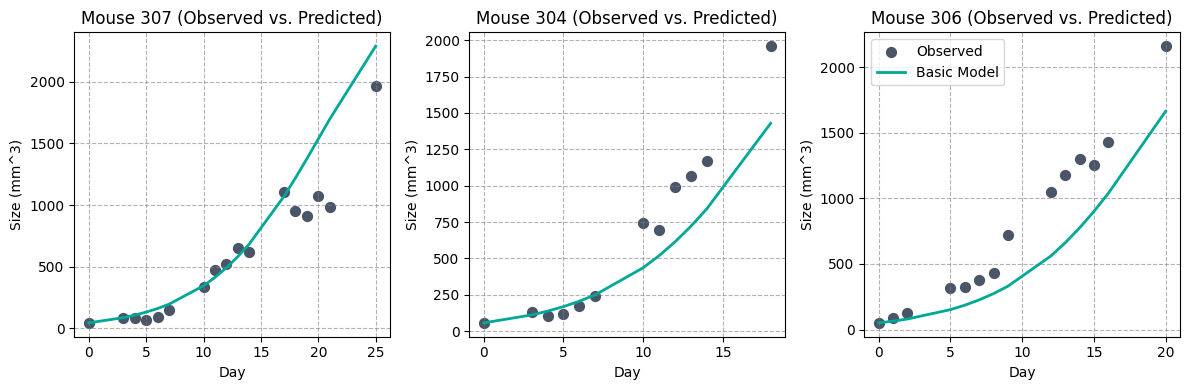

In [27]:
# Group 3 (Only radiation)
mice_grp3 = data[data["Group"] == 3]
id1, id2, id3 = random.sample(list(mice_grp3["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r_s = results_df["r_s"].iloc[0]
r_r = results_df["r_r"].iloc[0]
mu = results_df["mu"].iloc[0]
K = results_df["K"].iloc[0]
al = results_df.loc[results_df["Group"]==3, "al"].iloc[0]

D = True

sim_df1 = simulate_tumor_advanced(
    T0=T0_1,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor_advanced(
    T0=T0_2,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor_advanced(
    T0=T0_3,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig10.png", dpi=300, bbox_inches="tight")
plt.show()

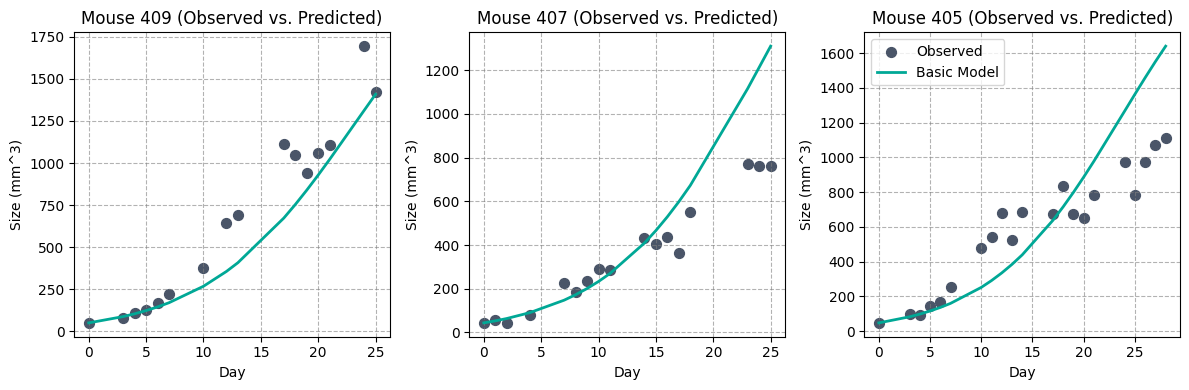

In [29]:
# Group 4 (Drug + Radiation)
mice_grp4 = data[data["Group"] == 4]
id1, id2, id3 = random.sample(list(mice_grp4["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r_s = results_df["r_s"].iloc[0]
r_r = results_df["r_r"].iloc[0]
mu = results_df["mu"].iloc[0]
K = results_df["K"].iloc[0]
al = results_df.loc[results_df["Group"]==4, "al"].iloc[0]

D = True

sim_df1 = simulate_tumor_advanced(
    T0=T0_1,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor_advanced(
    T0=T0_2,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor_advanced(
    T0=T0_3,
    r_s=r_s,
    r_r=r_r,
    K=K,
    al=al,
    mu=mu,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig7.png", dpi=300, bbox_inches="tight")
plt.show()

The advanced model seems to better fit the data corresponding to trated groups. This observation will also be validated in the following notebook.